In [ ]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.fft import rfft, rfftfreq

# =========================================================
# PARAMETERS
# =========================================================
omega0 = 1.0
alpha = 1.0
F = 0.2
Omega = 0.8

hbar = -1.0      # convergence-control parameter
M_order = 5      # HAM order
Nh = 5           # number of harmonics kept

T = 2*pi/Omega
t = np.linspace(0, 50*T, 50000)

# =========================================================
# HELPER: Fourier projection
# =========================================================
def fourier_coefficients(signal, t, Nh):
    coeffs = []
    for n in range(1, Nh+1):
        basis = np.cos(n*Omega*t)
        A = 2/T * np.trapz(signal * basis, t)
        coeffs.append(A)
    return np.array(coeffs)

# =========================================================
# HAM IMPLEMENTATION
# =========================================================
# initial guess
A0 = F / (omega0**2 - Omega**2)
x_series = A0 * np.cos(Omega*t)

for m in range(1, M_order+1):

    # residual from previous approximation
    x_prev = x_series

    xdd = np.gradient(np.gradient(x_prev, t), t)
    residual = xdd + omega0**2*x_prev + alpha*x_prev**3 - F*np.cos(Omega*t)

    # deformation equation:
    # (d^2/dt^2 + Omega^2) x_m = hbar * residual
    rhs = hbar * residual

    # solve in Fourier domain
    coeffs = fourier_coefficients(rhs, t, Nh)

    x_m = np.zeros_like(t)
    for n, A in enumerate(coeffs, start=1):
        denom = (-(n*Omega)**2 + Omega**2)
        if abs(denom) > 1e-6:
            x_m += (A/denom) * np.cos(n*Omega*t)

    x_series += x_m

# =========================================================
# NUMERICAL SOLUTION
# =========================================================
def duffing(t, y):
    x, v = y
    return [v,
            -omega0**2*x - alpha*x**3 + F*np.cos(Omega*t)]

sol = solve_ivp(duffing, [0, 200*T], [0, 0], max_step=0.01)

t_num = sol.t
x_num = sol.y[0]

# take last portion for steady state
steady_idx = int(0.8*len(t_num))
t_ss = t_num[steady_idx:]
x_ss = x_num[steady_idx:]

# FFT amplitude
freqs = rfftfreq(len(t_ss), t_ss[1]-t_ss[0])
X_fft = np.abs(rfft(x_ss))
idx = np.argmin(np.abs(freqs - Omega/(2*pi)))

amp_numeric = 2*X_fft[idx]/len(t_ss)

# HAM amplitude at fundamental
amp_ham = np.max(x_series[-int(5*T/(t[1]-t[0])):])



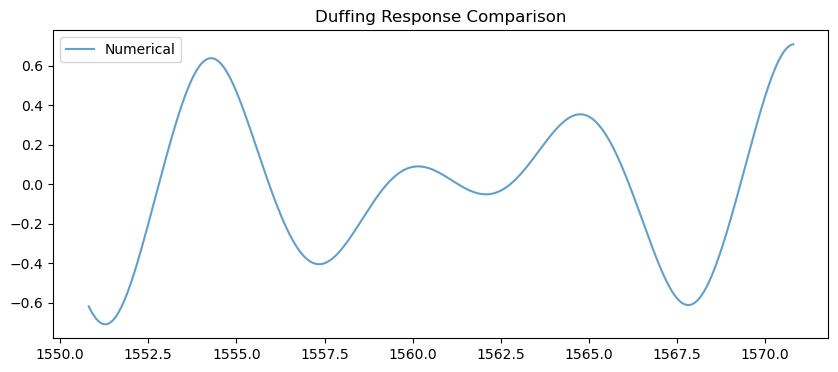

HAM amplitude (approx): 6.861697095001657e+43
Numerical amplitude: 0.3121376919860047


In [2]:

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(10,4))
# plt.plot(t[-2000:], x_series[-2000:], label="HAM")
plt.plot(t_ss[-2000:], x_ss[-2000:], label="Numerical", alpha=0.7)
plt.legend()
plt.title("Duffing Response Comparison")
plt.show()

print("HAM amplitude (approx):", amp_ham)
print("Numerical amplitude:", amp_numeric)